# 12 Valley Recovery Improvements

This notebook tackles a specific modeling problem from the project: the transformer is usually much better at matching **volatility peaks** than **volatility valleys**.

The experiments follow the four concrete improvement ideas we discussed:

1. add **retreat / cooldown features** that say whether volatility is fading,
2. try a more balanced **Huber loss on log-volatility**,
3. train a **regime-aware** version with separate low-vol and high-vol models,
4. apply simple **post-hoc calibration** on the best valley-oriented model.

To make the comparison honest, the notebook keeps one shared transformer family and changes only the parts needed for these valley-focused improvements.

In [1]:
from pathlib import Path
import copy
import math
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Base setup and new valley features

The baseline starts from the `regularized_small_fast_current` transformer family because it is compact and relatively stable.

The new valley-oriented features are designed to answer one question the earlier feature sets only captured weakly: **is volatility already cooling down?**

The added features are:

- short-vs-medium volatility ratios,
- medium-vs-long volatility ratios,
- a longer-horizon VIX distance signal,
- days since the last large absolute return,
- days since the last volatility spike.


In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date']).sort_values(['Ticker', 'Date']).reset_index(drop=True)

# This is the same fast-current feature family used in the earlier transformer notebooks.
fast_current_features = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'realized_vol_5d', 'realized_vol_21d', 'realized_vol_63d',
    'hist_vol_5d', 'hist_vol_21d',
    'volume_zscore_21d', 'abs_return_mean_5d', 'parkinson_vol_5d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
    'volume_zscore_5d', 'return_mean_5d', 'realized_vol_10d', 'parkinson_vol_21d',
    'mkt_SPY_proxy_range', 'mkt_QQQ_proxy_range', 'mkt_IWM_proxy_range',
    'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
]

train_mask = model_df['Date'].dt.year <= 2023
large_move_threshold = float(model_df.loc[train_mask, 'abs_return'].quantile(0.90))
vol_spike_threshold = float(model_df.loc[train_mask, 'realized_vol_5d'].quantile(0.85))

def days_since_event(flag_series):
    days = []
    counter = None
    for flag in flag_series:
        if bool(flag):
            counter = 0
        elif counter is None:
            counter = 999
        else:
            counter += 1
        days.append(counter)
    return pd.Series(days, index=flag_series.index)

# The ratio features tell us whether short-term volatility is already decaying relative to slower regimes.
eps = 1e-8
model_df['rv_ratio_5_21'] = model_df['realized_vol_5d'] / (model_df['realized_vol_21d'] + eps)
model_df['rv_ratio_21_63'] = model_df['realized_vol_21d'] / (model_df['realized_vol_63d'] + eps)
model_df['hist_ratio_5_21'] = model_df['hist_vol_5d'] / (model_df['hist_vol_21d'] + eps)
model_df['hist_ratio_21_63'] = model_df['hist_vol_21d'] / (model_df['hist_vol_63d'] + eps)
model_df['macro_^VIX_proxy_level_zscore_63d'] = model_df['macro_^VIX_proxy_level_zscore_63d'].fillna(0.0)

model_df['days_since_large_move'] = model_df.groupby('Ticker', sort=False)['abs_return'].transform(
    lambda s: days_since_event(s >= large_move_threshold)
)
model_df['days_since_vol_spike'] = model_df.groupby('Ticker', sort=False)['realized_vol_5d'].transform(
    lambda s: days_since_event(s >= vol_spike_threshold)
)
model_df['days_since_large_move'] = np.log1p(model_df['days_since_large_move'].clip(upper=252))
model_df['days_since_vol_spike'] = np.log1p(model_df['days_since_vol_spike'].clip(upper=252))

valley_extra_features = [
    'rv_ratio_5_21', 'rv_ratio_21_63', 'hist_ratio_5_21', 'hist_ratio_21_63',
    'macro_^VIX_proxy_level_zscore_63d', 'days_since_large_move', 'days_since_vol_spike',
]

feature_sets = {
    'fast_current': fast_current_features,
    'fast_current_plus_valley': fast_current_features + valley_extra_features,
}

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']
train_end_year = 2023
validation_year = 2024
test_year = 2025

display(pd.DataFrame({'feature_set': list(feature_sets.keys()), 'feature_count': [len(v) for v in feature_sets.values()]}))
pd.DataFrame({'new_valley_features': valley_extra_features})

/var/folders/8v/k04t35bn1pg6dmr6x1fkn6q00000gn/T/ipykernel_8730/3633167354.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df['hist_ratio_21_63'] = model_df['hist_vol_21d'] / (model_df['hist_vol_63d'] + eps)
/var/folders/8v/k04t35bn1pg6dmr6x1fkn6q00000gn/T/ipykernel_8730/3633167354.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_df['days_since_large_move'] = model_df.groupby('Ticker', sort=False)['abs_return'].transform(
/var/folders/8v/k04t35bn1pg6dmr6x1fkn6q00000gn/T/ipykernel_8730/3633167354.py:47: Perfo

,feature_set,feature_count
0,fast_current,31
1,fast_current_plus_valley,38


,new_valley_features
0,rv_ratio_5_21
1,rv_ratio_21_63
2,hist_ratio_5_21
3,hist_ratio_21_63
4,macro_^VIX_proxy_level_zscore_63d
5,days_since_large_move
6,days_since_vol_spike


## Experiments

The notebook runs four uncalibrated experiments first:

1. `baseline_fast_mse`: old fast-current model as a reference point,
2. `valley_features_mse`: same architecture, plus the new cooldown features,
3. `valley_features_huber`: same features, but a more balanced robust loss,
4. `regime_aware_huber`: separate low-vol and high-vol models, each using the valley feature set.

After that, the notebook calibrates the strongest valley-oriented model with both linear and isotonic calibration.

In [3]:
experiments = [
    {
        'name': 'baseline_fast_mse',
        'feature_set': 'fast_current',
        'loss_name': 'mse',
        'regime_aware': False,
    },
    {
        'name': 'valley_features_mse',
        'feature_set': 'fast_current_plus_valley',
        'loss_name': 'mse',
        'regime_aware': False,
    },
    {
        'name': 'valley_features_huber',
        'feature_set': 'fast_current_plus_valley',
        'loss_name': 'huber',
        'regime_aware': False,
        'delta': 0.10,
    },
    {
        'name': 'regime_aware_huber',
        'feature_set': 'fast_current_plus_valley',
        'loss_name': 'huber',
        'regime_aware': True,
        'delta': 0.10,
    },
]

model_config = {
    'lookback': 90,
    'd_model': 64,
    'nhead': 4,
    'num_layers': 2,
    'dim_feedforward': 128,
    'dropout': 0.3,
    'ticker_embedding_dim': 8,
    'batch_size': 512,
    'epochs': 30,
    'patience': 6,
    'learning_rate': 3e-4,
    'weight_decay': 1e-3,
}

pd.DataFrame(experiments)

,name,feature_set,loss_name,regime_aware,delta
0,baseline_fast_mse,fast_current,mse,False,NaN
1,valley_features_mse,fast_current_plus_valley,mse,False,NaN
2,valley_features_huber,fast_current_plus_valley,huber,False,0.1
3,regime_aware_huber,fast_current_plus_valley,huber,True,0.1


## Shared data pipeline and metrics

Two extra diagnostics are important here beyond the usual overall metrics:

- `low_vol_mae`: MAE on the lowest 20% of actual volatility in that split,
- `low_vol_bias`: mean(prediction - actual) on that same low-vol subset.

A positive low-vol bias means the model is still lifting the valleys too high.

In [4]:
class RollingSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years, regime_filter=None):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.regime_filter = regime_filter
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                if panel['dates'][end_idx].year not in self.allowed_years:
                    continue
                regime = panel['regime_flag'][end_idx]
                if self.regime_filter is not None and regime != self.regime_filter:
                    continue
                self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        x = panel['features'][start_idx:end_idx + 1]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'y_log': torch.tensor(panel['target_log'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'regime_flag': torch.tensor(panel['regime_flag'][end_idx], dtype=torch.long),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class VolatilityTransformer(nn.Module):
    def __init__(self, input_dim, num_tickers, d_model, nhead, num_layers, dim_feedforward, dropout, ticker_embedding_dim, max_len):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(d_model + ticker_embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx):
        x = self.input_proj(x)
        x = self.positional_encoding(x)
        encoded = self.encoder(x)
        sequence_repr = encoded[:, -1, :]
        ticker_repr = self.ticker_embedding(ticker_idx)
        output = self.head(torch.cat([sequence_repr, ticker_repr], dim=1)).squeeze(-1)
        return output

def prepare_data(feature_list, lookback, batch_size):
    selected_columns = list(dict.fromkeys(target_columns + ['realized_vol_21d'] + feature_list))
    experiment_df = model_df[selected_columns].copy()
    experiment_df = experiment_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = experiment_df['Date'].dt.year <= train_end_year
    # We define a simple regime flag from the training median of medium-horizon realized volatility.
    regime_threshold = float(experiment_df.loc[train_mask, 'realized_vol_21d'].median())
    experiment_df['regime_flag'] = (experiment_df['realized_vol_21d'] > regime_threshold).astype(int)
    feature_mean = experiment_df.loc[train_mask, feature_list].mean()
    feature_std = experiment_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    experiment_df[feature_list] = (experiment_df[feature_list] - feature_mean) / feature_std
    ticker_levels = sorted(experiment_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped_panels = {}
    for ticker, group in experiment_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped_panels[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'target_log': group['log_fvol_5d'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
            'regime_flag': group['regime_flag'].to_numpy(dtype=np.int64),
        }
    return {
        'ticker_levels': ticker_levels,
        'ticker_to_idx': ticker_to_idx,
        'grouped_panels': grouped_panels,
        'regime_threshold': regime_threshold,
        'train_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, range(2016, train_end_year + 1)), batch_size=batch_size, shuffle=True, num_workers=0),
        'val_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, [validation_year]), batch_size=batch_size, shuffle=False, num_workers=0),
        'test_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, [test_year]), batch_size=batch_size, shuffle=False, num_workers=0),
        'train_low_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, range(2016, train_end_year + 1), regime_filter=0), batch_size=batch_size, shuffle=True, num_workers=0),
        'train_high_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, range(2016, train_end_year + 1), regime_filter=1), batch_size=batch_size, shuffle=True, num_workers=0),
        'val_low_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, [validation_year], regime_filter=0), batch_size=batch_size, shuffle=False, num_workers=0),
        'val_high_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, [validation_year], regime_filter=1), batch_size=batch_size, shuffle=False, num_workers=0),
        'test_low_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, [test_year], regime_filter=0), batch_size=batch_size, shuffle=False, num_workers=0),
        'test_high_loader': DataLoader(RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, [test_year], regime_filter=1), batch_size=batch_size, shuffle=False, num_workers=0),
    }

def compute_loss(loss_name, pred_log, y_log, y_vol, delta=0.10):
    if loss_name == 'mse':
        return torch.mean((pred_log - y_log) ** 2)
    if loss_name == 'huber':
        return F.huber_loss(pred_log, y_log, reduction='mean', delta=delta)
    raise ValueError(f'Unknown loss: {loss_name}')

def run_epoch(model, dataloader, loss_name, delta=0.10, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        y_log = batch['y_log'].to(DEVICE)
        y_vol = batch['y_vol'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx)
            loss = compute_loss(loss_name, pred, y_log, y_vol, delta=delta)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_items += batch_size
    return total_loss / total_items

def build_model(input_dim, num_tickers):
    return VolatilityTransformer(
        input_dim=input_dim,
        num_tickers=num_tickers,
        d_model=model_config['d_model'],
        nhead=model_config['nhead'],
        num_layers=model_config['num_layers'],
        dim_feedforward=model_config['dim_feedforward'],
        dropout=model_config['dropout'],
        ticker_embedding_dim=model_config['ticker_embedding_dim'],
        max_len=model_config['lookback'],
    ).to(DEVICE)

def train_single_model(model, train_loader, val_loader, loss_name, delta=0.10):
    optimizer = torch.optim.AdamW(model.parameters(), lr=model_config['learning_rate'], weight_decay=model_config['weight_decay'])
    best_state = None
    best_val_loss = float('inf')
    best_epoch = None
    epochs_without_improvement = 0
    history_rows = []
    for epoch in range(1, model_config['epochs'] + 1):
        train_loss = run_epoch(model, train_loader, loss_name, delta=delta, optimizer=optimizer)
        val_loss = run_epoch(model, val_loader, loss_name, delta=delta, optimizer=None)
        history_rows.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= model_config['patience']:
            break
    model.load_state_dict(best_state)
    return model, best_epoch, pd.DataFrame(history_rows)

@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        pred_log = model(x, ticker_idx).detach().cpu().numpy()
        pred_vol = np.exp(np.clip(pred_log, -6.0, 6.0))
        y_vol = batch['y_vol'].detach().cpu().numpy()
        regime_flag = batch['regime_flag'].detach().cpu().numpy()
        for date, ticker, actual, prediction, regime in zip(batch['date'], batch['ticker'], y_vol, pred_vol, regime_flag):
            rows.append({
                'Date': pd.to_datetime(date),
                'Ticker': ticker,
                'fvol_5d': float(actual),
                'prediction': float(prediction),
                'regime_flag': int(regime),
            })
    return pd.DataFrame(rows)

def evaluate(prediction_df):
    y_true = np.asarray(prediction_df['fvol_5d'], dtype=float)
    y_pred = np.clip(np.asarray(prediction_df['prediction'], dtype=float), 1e-8, None)
    errors = y_true - y_pred
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    low_cut = np.quantile(y_true, 0.20)
    low_mask = y_true <= low_cut
    low_errors = y_pred[low_mask] - y_true[low_mask]
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
        'corr': float(corr),
        'low_vol_mae': float(np.mean(np.abs(low_errors))),
        'low_vol_bias': float(np.mean(low_errors)),
        'low_vol_cut': float(low_cut),
    }

def decile_table(prediction_df):
    table = prediction_df.copy()
    table['actual_decile'] = pd.qcut(table['fvol_5d'], q=10, labels=False, duplicates='drop')
    return table.groupby('actual_decile', as_index=False).agg(actual_mean=('fvol_5d', 'mean'), predicted_mean=('prediction', 'mean'))

def train_standard_experiment(spec):
    feature_list = feature_sets[spec['feature_set']]
    data = prepare_data(feature_list, lookback=model_config['lookback'], batch_size=model_config['batch_size'])
    model = build_model(len(feature_list), len(data['ticker_levels']))
    model, best_epoch, history_df = train_single_model(model, data['train_loader'], data['val_loader'], spec['loss_name'], delta=spec.get('delta', 0.10))
    val_predictions = predict_dataset(model, data['val_loader'])
    test_predictions = predict_dataset(model, data['test_loader'])
    val_metrics = evaluate(val_predictions)
    test_metrics = evaluate(test_predictions)
    summary = {
        'experiment': spec['name'],
        'feature_set': spec['feature_set'],
        'loss_name': spec['loss_name'],
        'regime_aware': spec['regime_aware'],
        'best_epoch': best_epoch,
        'val_rmse': val_metrics['rmse'],
        'val_mae': val_metrics['mae'],
        'val_qlike': val_metrics['qlike'],
        'val_corr': val_metrics['corr'],
        'val_low_vol_mae': val_metrics['low_vol_mae'],
        'val_low_vol_bias': val_metrics['low_vol_bias'],
        'val_low_vol_abs_bias': abs(val_metrics['low_vol_bias']),
        'test_rmse': test_metrics['rmse'],
        'test_mae': test_metrics['mae'],
        'test_qlike': test_metrics['qlike'],
        'test_corr': test_metrics['corr'],
        'test_low_vol_mae': test_metrics['low_vol_mae'],
        'test_low_vol_bias': test_metrics['low_vol_bias'],
        'test_low_vol_abs_bias': abs(test_metrics['low_vol_bias']),
    }
    return summary, history_df.assign(experiment=spec['name']), val_predictions, test_predictions

def train_regime_aware_experiment(spec):
    feature_list = feature_sets[spec['feature_set']]
    data = prepare_data(feature_list, lookback=model_config['lookback'], batch_size=model_config['batch_size'])
    low_model = build_model(len(feature_list), len(data['ticker_levels']))
    high_model = build_model(len(feature_list), len(data['ticker_levels']))
    low_model, low_best_epoch, low_history = train_single_model(low_model, data['train_low_loader'], data['val_low_loader'], spec['loss_name'], delta=spec.get('delta', 0.10))
    high_model, high_best_epoch, high_history = train_single_model(high_model, data['train_high_loader'], data['val_high_loader'], spec['loss_name'], delta=spec.get('delta', 0.10))
    val_low = predict_dataset(low_model, data['val_low_loader'])
    val_high = predict_dataset(high_model, data['val_high_loader'])
    test_low = predict_dataset(low_model, data['test_low_loader'])
    test_high = predict_dataset(high_model, data['test_high_loader'])
    val_predictions = pd.concat([val_low, val_high], ignore_index=True).sort_values(['Date', 'Ticker']).reset_index(drop=True)
    test_predictions = pd.concat([test_low, test_high], ignore_index=True).sort_values(['Date', 'Ticker']).reset_index(drop=True)
    val_metrics = evaluate(val_predictions)
    test_metrics = evaluate(test_predictions)
    history_df = pd.concat([
        low_history.assign(experiment=f"{spec['name']}_low"),
        high_history.assign(experiment=f"{spec['name']}_high"),
    ], ignore_index=True)
    summary = {
        'experiment': spec['name'],
        'feature_set': spec['feature_set'],
        'loss_name': spec['loss_name'],
        'regime_aware': spec['regime_aware'],
        'best_epoch': int(max(low_best_epoch, high_best_epoch)),
        'val_rmse': val_metrics['rmse'],
        'val_mae': val_metrics['mae'],
        'val_qlike': val_metrics['qlike'],
        'val_corr': val_metrics['corr'],
        'val_low_vol_mae': val_metrics['low_vol_mae'],
        'val_low_vol_bias': val_metrics['low_vol_bias'],
        'val_low_vol_abs_bias': abs(val_metrics['low_vol_bias']),
        'test_rmse': test_metrics['rmse'],
        'test_mae': test_metrics['mae'],
        'test_qlike': test_metrics['qlike'],
        'test_corr': test_metrics['corr'],
        'test_low_vol_mae': test_metrics['low_vol_mae'],
        'test_low_vol_bias': test_metrics['low_vol_bias'],
        'test_low_vol_abs_bias': abs(test_metrics['low_vol_bias']),
    }
    return summary, history_df, val_predictions, test_predictions

def fit_and_apply_calibrators(val_predictions, test_predictions):
    x_val = val_predictions['prediction'].to_numpy().reshape(-1, 1)
    y_val = val_predictions['fvol_5d'].to_numpy()
    x_test = test_predictions['prediction'].to_numpy().reshape(-1, 1)

    linear = LinearRegression().fit(x_val, y_val)
    linear_test = test_predictions.copy()
    linear_test['prediction'] = np.clip(linear.predict(x_test), 1e-8, None)

    isotonic = IsotonicRegression(out_of_bounds='clip').fit(val_predictions['prediction'], y_val)
    isotonic_test = test_predictions.copy()
    isotonic_test['prediction'] = np.clip(isotonic.predict(test_predictions['prediction']), 1e-8, None)
    return linear_test, isotonic_test


## Run the uncalibrated experiments

The first summary table tells us whether the new features, the Huber loss, or the regime-aware split helps with valley recovery before any calibration is applied.

In [5]:
summaries = []
history_frames = []
val_prediction_map = {}
test_prediction_map = {}

for spec in experiments:
    if spec['regime_aware']:
        summary, history_df, val_predictions, test_predictions = train_regime_aware_experiment(spec)
    else:
        summary, history_df, val_predictions, test_predictions = train_standard_experiment(spec)
    summaries.append(summary)
    history_frames.append(history_df)
    val_prediction_map[spec['name']] = val_predictions
    test_prediction_map[spec['name']] = test_predictions

summary_df = pd.DataFrame(summaries).sort_values(['val_low_vol_mae', 'val_low_vol_abs_bias']).reset_index(drop=True)
history_df = pd.concat(history_frames, ignore_index=True)
summary_df

,experiment,feature_set,loss_name,regime_aware,best_epoch,val_rmse,val_mae,val_qlike,val_corr,val_low_vol_mae,val_low_vol_bias,val_low_vol_abs_bias,test_rmse,test_mae,test_qlike,test_corr,test_low_vol_mae,test_low_vol_bias,test_low_vol_abs_bias
0,baseline_fast_mse,fast_current,mse,False,3,0.142936,0.082789,-1.544884,0.451300,0.065396,0.062808,0.062808,0.165006,0.097433,-1.261139,0.490015,0.067737,0.064827,0.064827
1,valley_features_mse,fast_current_plus_valley,mse,False,5,0.141582,0.082342,-1.560623,0.464099,0.067166,0.064212,0.064212,0.164588,0.097992,-1.291497,0.487194,0.068653,0.065752,0.065752
2,regime_aware_huber,fast_current_plus_valley,huber,True,10,0.141876,0.083062,-1.571474,0.455777,0.068058,0.065686,0.065686,0.164174,0.097969,-1.296785,0.486865,0.070110,0.067622,0.067622
3,valley_features_huber,fast_current_plus_valley,huber,False,11,0.140400,0.082168,-1.615260,0.468578,0.070887,0.069061,0.069061,0.163725,0.098989,-1.322010,0.477773,0.078366,0.075681,0.075681


In [6]:
history_df

,epoch,train_loss,val_loss,experiment
0,1,0.449512,0.254922,baseline_fast_mse
1,2,0.260058,0.244070,baseline_fast_mse
2,3,0.251891,0.239417,baseline_fast_mse
3,4,0.245598,0.239749,baseline_fast_mse
4,5,0.241373,0.243008,baseline_fast_mse
...,...,...,...,...
59,7,0.030798,0.033876,regime_aware_huber_high
60,8,0.030545,0.033899,regime_aware_huber_high
61,9,0.030434,0.033695,regime_aware_huber_high
62,10,0.030247,0.033906,regime_aware_huber_high


## Calibrate the strongest valley-oriented model

We choose the best uncalibrated model by validation `low_vol_mae`, then fit both a linear calibrator and an isotonic calibrator on the validation predictions.

In [7]:
best_valley_model = summary_df.iloc[0]['experiment']
best_valley_model

'baseline_fast_mse'

In [8]:
linear_test, isotonic_test = fit_and_apply_calibrators(val_prediction_map[best_valley_model], test_prediction_map[best_valley_model])
calibration_rows = []
for name, pred_df in [
    ('best_uncalibrated', test_prediction_map[best_valley_model]),
    ('linear_calibrated', linear_test),
    ('isotonic_calibrated', isotonic_test),
]:
    metrics = evaluate(pred_df)
    metrics['low_vol_abs_bias'] = abs(metrics['low_vol_bias'])
    metrics['experiment'] = name
    calibration_rows.append(metrics)
calibration_df = pd.DataFrame(calibration_rows)[['experiment','rmse','mae','qlike','corr','low_vol_mae','low_vol_bias','low_vol_abs_bias']]
calibration_df

,experiment,rmse,mae,qlike,corr,low_vol_mae,low_vol_bias,low_vol_abs_bias
0,best_uncalibrated,0.165006,0.097433,-1.261139,0.490015,0.067737,0.064827,0.064827
1,linear_calibrated,0.160804,0.099459,-1.444094,0.490015,0.093432,0.092867,0.092867
2,isotonic_calibrated,0.162263,0.099163,-1.419002,0.479466,0.093197,0.092144,0.092144


## Valley calibration table

This decile table focuses on how much each model lifts the low-volatility buckets above the true values.

In [9]:
decile_tables = {
    'baseline_fast_mse': decile_table(test_prediction_map['baseline_fast_mse']),
    best_valley_model: decile_table(test_prediction_map[best_valley_model]),
    'isotonic_calibrated': decile_table(isotonic_test),
}
for name, table in decile_tables.items():
    print(name)
    display(table)
    print()


baseline_fast_mse


,actual_decile,actual_mean,predicted_mean
0,0,0.083271,0.157619
1,1,0.122678,0.177977
2,2,0.150164,0.188676
3,3,0.175348,0.198784
4,4,0.201213,0.206550
5,5,0.230242,0.217884
6,6,0.262382,0.228164
7,7,0.304798,0.248891
8,8,0.381788,0.269142
9,9,0.685255,0.324392



isotonic_calibrated


,actual_decile,actual_mean,predicted_mean
0,0,0.083271,0.184628
1,1,0.122678,0.205603
2,2,0.150164,0.216503
3,3,0.175348,0.225867
4,4,0.201213,0.233182
5,5,0.230242,0.244471
6,6,0.262382,0.254873
7,7,0.304798,0.278329
8,8,0.381788,0.297983
9,9,0.685255,0.366837


## Five-stock comparison plot

The stock plot overlays three curves:

- the original baseline,
- the best uncalibrated valley-oriented model,
- the isotonic-calibrated version of that same model.

This is the easiest way to see whether valleys are being pulled downward without destroying the peaks.

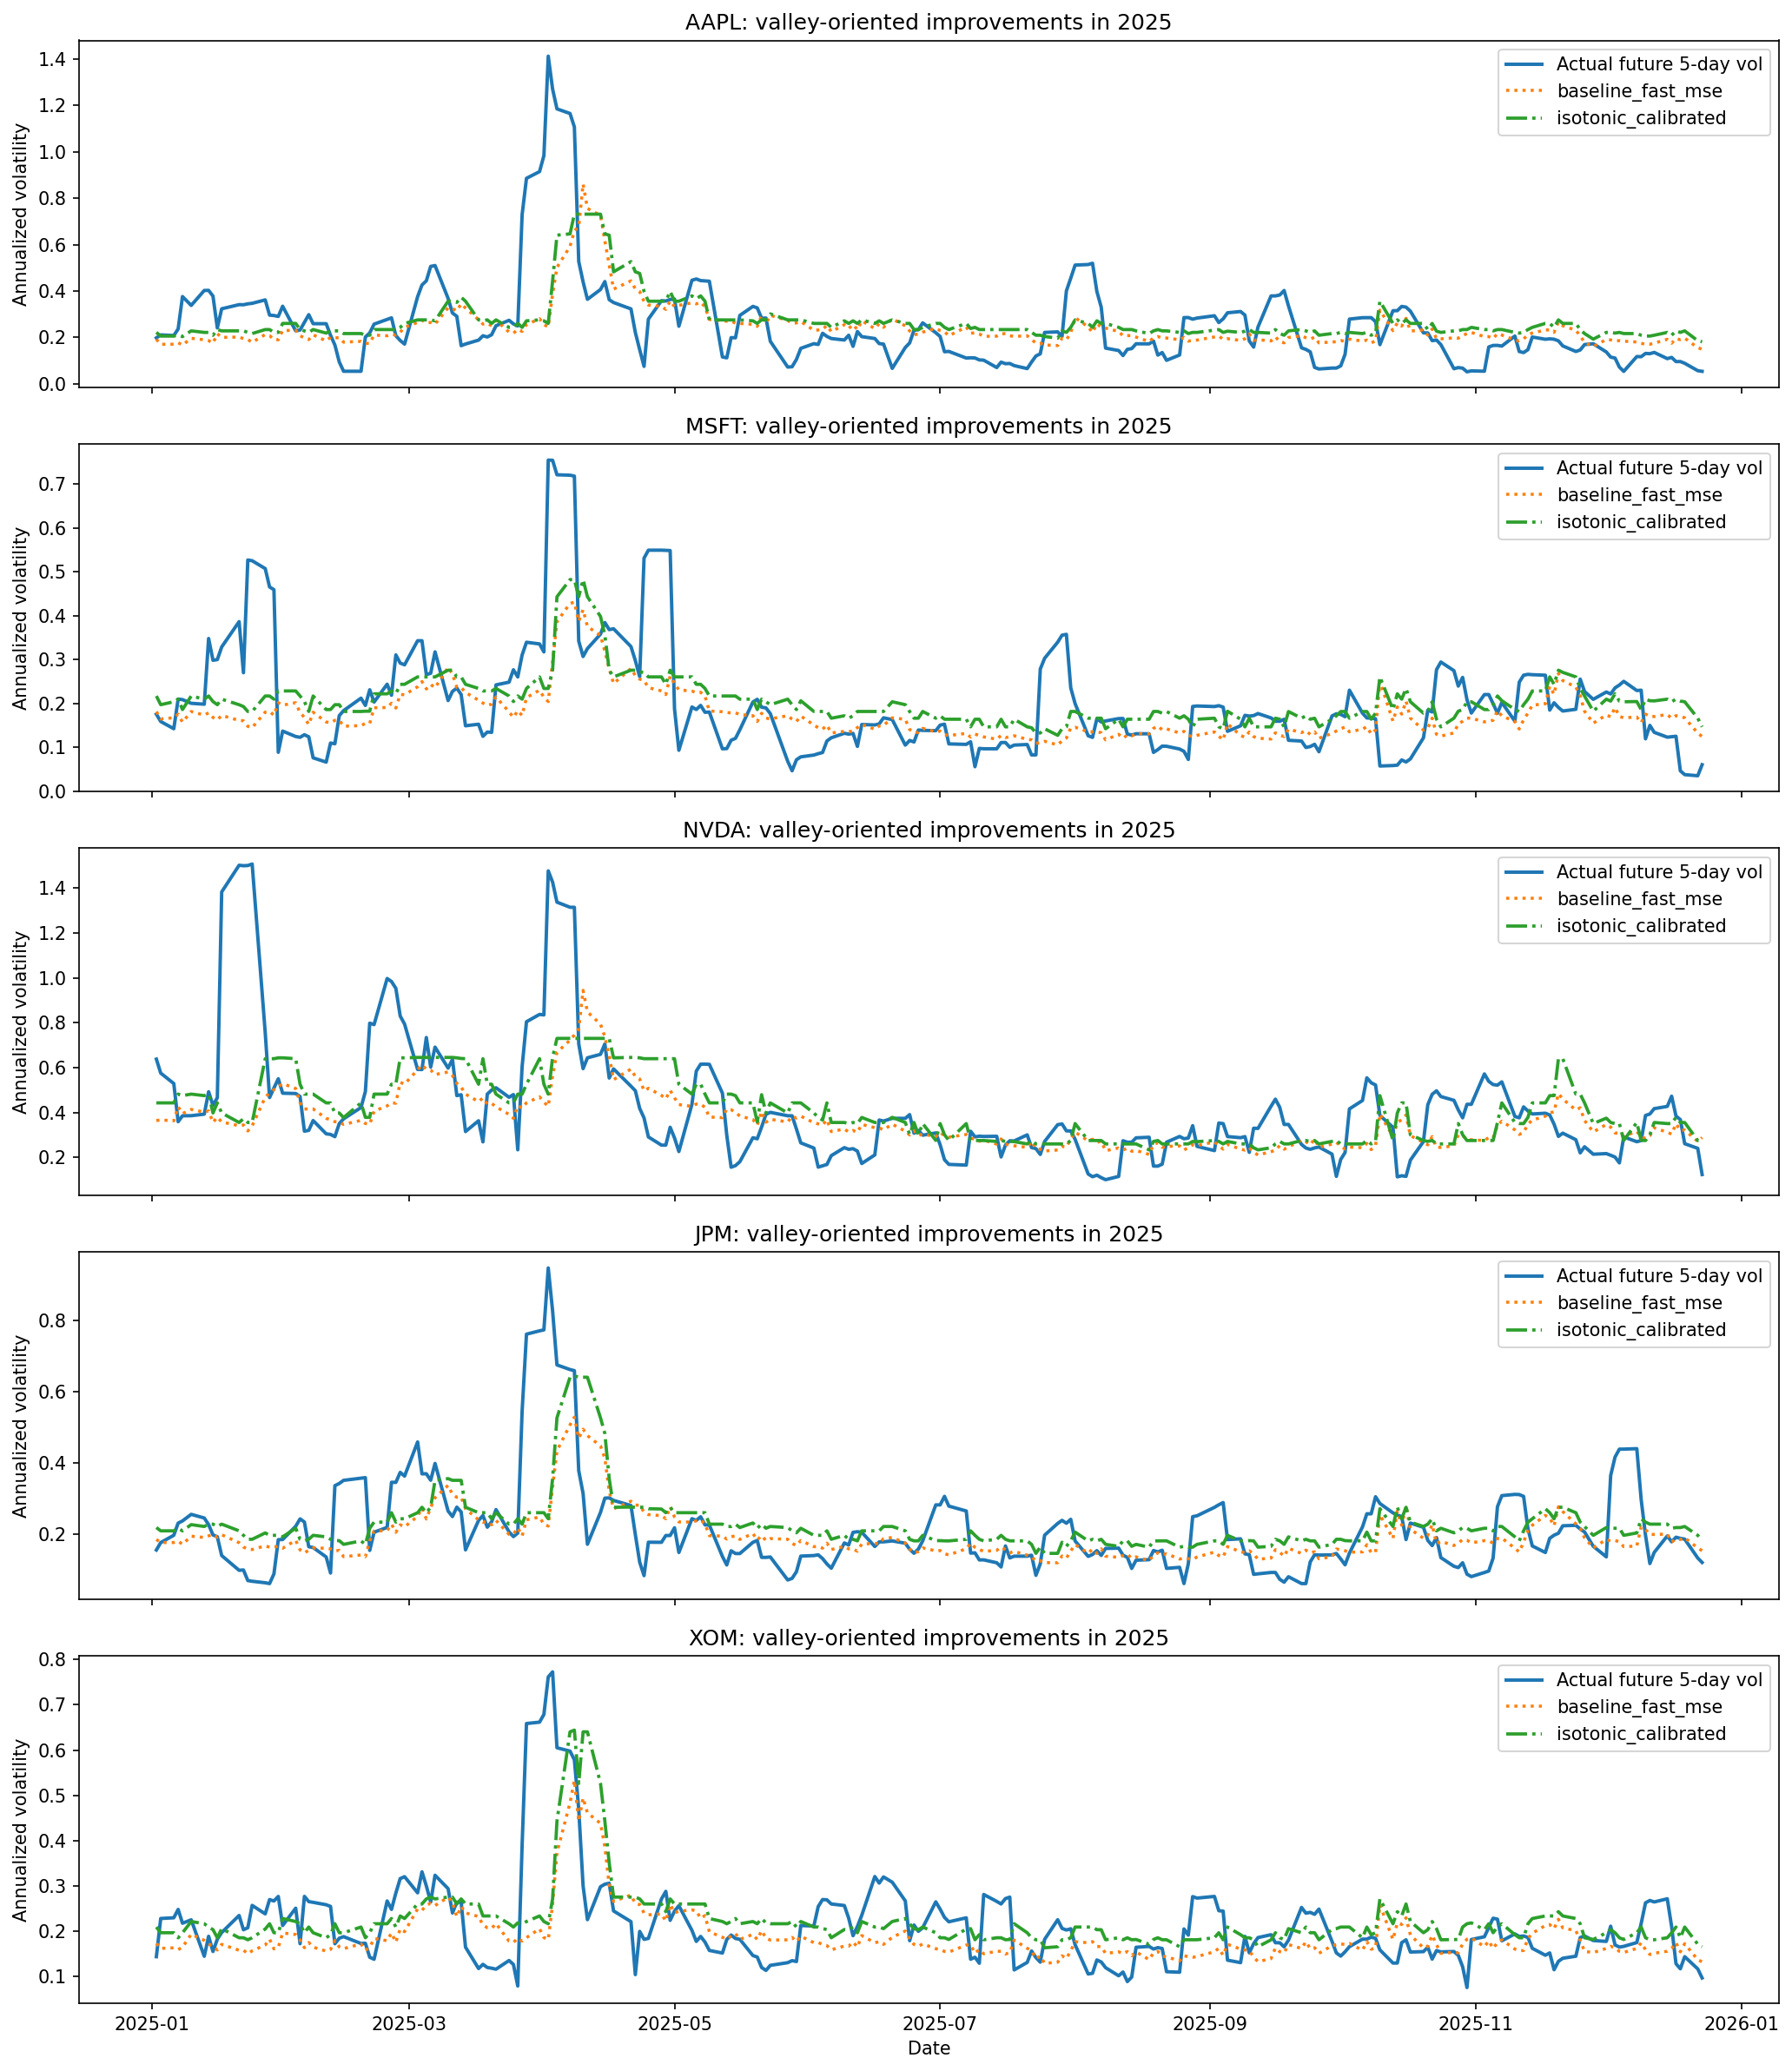

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/transformer_valley_improvements_5stocks.png')

In [10]:
plot_sources = {
    'baseline_fast_mse': test_prediction_map['baseline_fast_mse'],
    best_valley_model: test_prediction_map[best_valley_model],
    'isotonic_calibrated': isotonic_test,
}
overlay_names = []
for name in ['baseline_fast_mse', best_valley_model, 'isotonic_calibrated']:
    if name not in overlay_names:
        overlay_names.append(name)

plot_df = plot_sources[overlay_names[0]].rename(columns={'prediction': overlay_names[0]})
for name in overlay_names[1:]:
    plot_df = plot_df.merge(plot_sources[name][['Date','Ticker','prediction']].rename(columns={'prediction': name}), on=['Date','Ticker'], how='left')

fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 16), sharex=True)
styles = {
    'baseline_fast_mse': ('--', 1.5),
    best_valley_model: (':', 1.7),
    'isotonic_calibrated': ('-.', 1.8),
}

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = plot_df[plot_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.9)
    for name in overlay_names:
        linestyle, linewidth = styles[name]
        ax.plot(stock_plot_df['Date'], stock_plot_df[name], label=name, linestyle=linestyle, linewidth=linewidth)
    ax.set_title(f'{ticker}: valley-oriented improvements in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

plot_path = FIGURE_DIR / 'transformer_valley_improvements_5stocks.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(plot_path)))

plot_path

## How to read the result

The best valley fix will usually look like this:

- `low_vol_mae` falls,
- `low_vol_bias` moves closer to zero,
- the bottom deciles of the decile table stop being systematically overpredicted,
- and the five-stock plot shows lower valleys without completely flattening the peaks.

That combination matters more here than simply winning on one overall metric.